<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/Deep_residual_learning_ResNet_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## Basic Residual Block

In [2]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        # First 3x3 convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Second 3x3 convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut (identity or projection)
        self.shortcut = nn.Sequential()

        # If dimensions change, we must match them
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Residual addition
        out += self.shortcut(x)

        out = F.relu(out)
        return out

## ResNet-20


In [3]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()

        self.in_channels = 16

        # Initial conv layer
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        # Residual layers
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)

        self.linear = nn.Linear(64, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []

        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels

        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)

        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)

        return out

In [4]:
def ResNet20():
    return ResNet(BasicBlock, [3,3,3])

model = ResNet20()
print(model)

ResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=

## how the model actually looks!

In [5]:
!pip install torchview

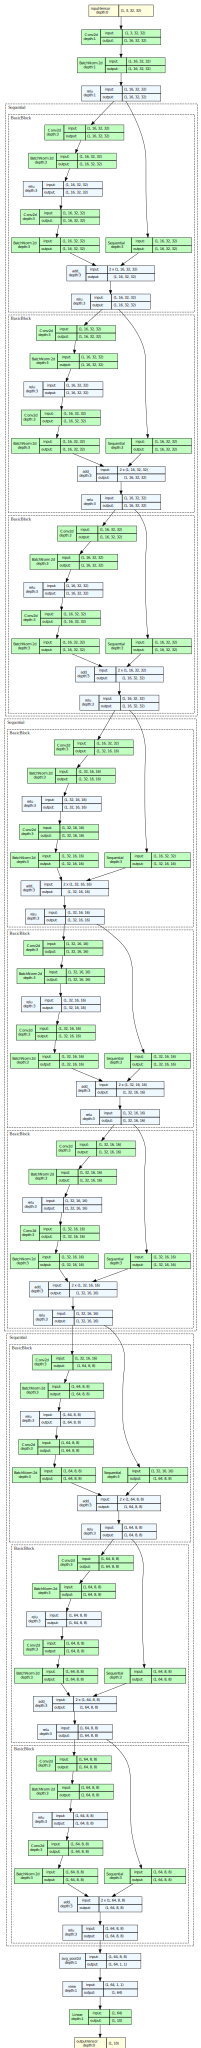

In [6]:
from torchview import draw_graph

model = ResNet20()

graph = draw_graph(model,
                   input_size=(1,3,32,32),
                   expand_nested=True,
                   graph_name="ResNet20")

graph.visual_graph

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

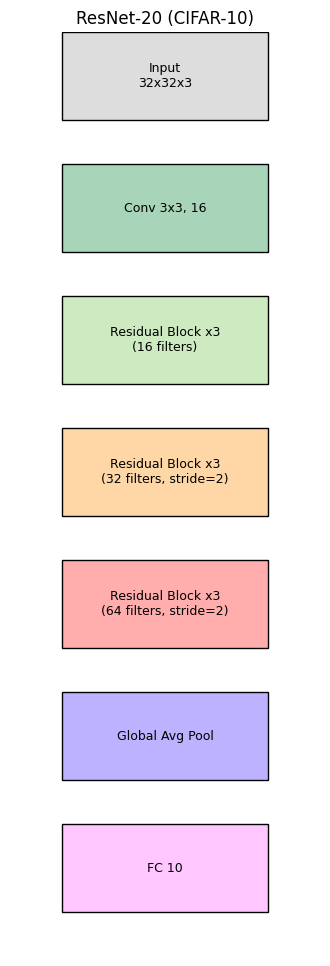

In [9]:
def draw_resnet20_diagram():
    fig, ax = plt.subplots(figsize=(4, 12))

    y = 0
    height = 0.8
    spacing = 1.2

    def block(label, color):
        nonlocal y
        rect = patches.Rectangle((0.5, y), 2, height,
                                 edgecolor='black',
                                 facecolor=color)
        ax.add_patch(rect)
        ax.text(1.5, y + height/2, label,
                ha='center', va='center', fontsize=9)
        y += spacing

    # Draw layers
    block("Input\n32x32x3", "#DDDDDD")
    block("Conv 3x3, 16", "#A8D5BA")

    block("Residual Block x3\n(16 filters)", "#CDEAC0")
    block("Residual Block x3\n(32 filters, stride=2)", "#FFD6A5")
    block("Residual Block x3\n(64 filters, stride=2)", "#FFADAD")

    block("Global Avg Pool", "#BDB2FF")
    block("FC 10", "#FFC6FF")

    ax.set_xlim(0, 3)
    ax.set_ylim(0, y)
    ax.axis("off")
    ax.invert_yaxis()

    plt.title("ResNet-20 (CIFAR-10)", fontsize=12)
    plt.show()

draw_resnet20_diagram()

## training and testing


In [10]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,
    download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False,
    download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128,
                         shuffle=True, num_workers=2)

testloader = DataLoader(testset, batch_size=128,
                        shuffle=False, num_workers=2)

classes = trainset.classes

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


In [12]:
model = ResNet20().to(device)

In [13]:
import torch.optim as optim

criterion = torch.nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),
                      lr=0.1,
                      momentum=0.9,
                      weight_decay=1e-4)

In [14]:
def train(epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    print(f"Epoch {epoch} | Loss: {total_loss:.3f} | "
          f"Train Acc: {100.*correct/total:.2f}%")

In [15]:
for epoch in range(1, 11):
    train(epoch)

Epoch 1 | Loss: 645.861 | Train Acc: 37.63%
Epoch 2 | Loss: 447.054 | Train Acc: 58.58%
Epoch 3 | Loss: 358.461 | Train Acc: 67.17%
Epoch 4 | Loss: 301.791 | Train Acc: 72.79%
Epoch 5 | Loss: 265.492 | Train Acc: 76.25%
Epoch 6 | Loss: 239.510 | Train Acc: 78.71%
Epoch 7 | Loss: 220.103 | Train Acc: 80.45%
Epoch 8 | Loss: 204.755 | Train Acc: 81.83%
Epoch 9 | Loss: 195.490 | Train Acc: 82.75%
Epoch 10 | Loss: 187.428 | Train Acc: 83.49%


In [16]:
def test():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    print(f"Test Accuracy: {100.*correct/total:.2f}%")

test()

Test Accuracy: 79.89%


Predicted: ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'truck', 'deer']
Actual   : ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog']


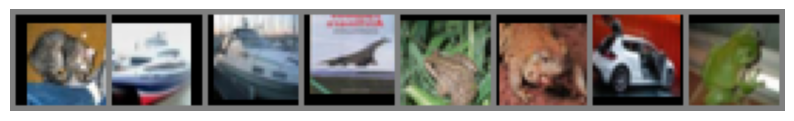

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis('off')

model.eval()
images, labels = next(iter(testloader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)

plt.figure(figsize=(10,5))
imshow(torchvision.utils.make_grid(images[:8].cpu()))
print("Predicted:", [classes[p] for p in predicted[:8]])
print("Actual   :", [classes[l] for l in labels[:8]])